# Black-Scholes Options Pricer for European Options

In [154]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## Model Inputs

| Parameter | Symbol | Definition |
| --------- |------- |----------- |
| Spot price | S | Current market price of the underlying stock |
| Strike price | K | Price at which the option can be exercised |
| Time to expiry | T | Time remaining until expity in years |
| Risk-free rate | r | Annualized risk-free interest rate |
| Volatility | sigma | Annualized standard deviation of returns |

In [155]:
def inputs():

    while True:
        #Spot price of the underlying asset
        S = float(input("Enter the spot price of the stock: "))
        if S > 0:
            break
        else:
            print("Invalid input. The stock price must be greater than 0.")
            
    while True:
        #Strike price
        K = float(input("Enter the strike price: "))
        if K > 0:
            break
        else:
            print("Invalid input. The strike price must be greater than 0.")

    while True:
        #Time to maturity
        T = float(input("Enter time to expiry: "))
        if T > 0:
            break
        else:
            print("Invalid input. The time to expiry must be greater than 0.")

    while True:
        #Risk-free rate
        r = float(input("Enter risk-free interest rate: "))
        if r > 0:
            break
        else:
            print("Invalid input. The risk-free interest rate must be greater than 0.")

    while True:
        #Volatility
        sigma = float(input("Enter volatility: "))
        if sigma > 0:
            break
        else:
            print("Invalid input. The volatility must be greater than 0.")
    
    return S, K, T, r, sigma

In [156]:
S, K, T, r, sigma = inputs()

Enter the spot price of the stock:  100
Enter the strike price:  110
Enter time to expiry:  1
Enter risk-free interest rate:  0.05
Enter volatility:  0.05


## Black-Scholes Pricing

$$d_1 = \frac{\ln{S/K} + (r + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}}$$

$$d_2 = d_1 - (\sigma\sqrt{T})$$

$$\newline$$

$$C = S \cdot N(d_1) - K \cdot e^{-rT} \cdot N(d_2)$$

$$P = K \cdot e^{-rT} \cdot N(-d_2) - S \cdot N(-d_1)$$

In [157]:
#Calculating d1 and d2

def parameters(S, K, T, r, sigma):
    d1 = (np.log(S/K) + (r + (0.5 * sigma ** 2)) * T) / (sigma * np.sqrt(T))
    d2 = d1 - (sigma * np.sqrt(T))

    return d1, d2

In [158]:
d1, d2 = parameters(S, K, T, r, sigma)

In [159]:
def fair_price(S, K, T, r, d1, d2):
    
    #Call option
    bs_call_price = (S * norm.cdf(d1)) - (K * np.exp(-r * T) * norm.cdf(d2))
    
    #Put option
    bs_put_price = (K * np.exp(-r * T) * norm.cdf(-d2)) - (S * norm.cdf(-d1))

    return bs_call_price, bs_put_price

In [160]:
bs_call_price, bs_put_price = fair_price(S, K, T, r, d1, d2)

In [161]:
def select_option_type(bs_call_price, bs_put_price):
    while True:
        option = str(input("Select the option type (call or put or both): ")).strip().lower()
        
        if option == "call":
            return bs_call_price

        elif option == "put":
            return bs_put_price

        elif option == "both":
            return bs_call_price, bs_put_price

        else:
            print("Invalid input.")

In [162]:
print(f"Call Price: ${bs_call_price:.4f}")
print(f"Put Price: ${bs_put_price:.4f}")

Call Price: $0.5078
Put Price: $5.1430


In [163]:
Option = select_option_type(bs_call_price, bs_put_price)

Select the option type (call or put or both):  Call


## Break Even Analysis

$$\text{Call break even} = K + C$$

$$\newline$$

$$\text{Put break even} = K - P$$

In [164]:
def break_even_price(K, bs_call_price, bs_put_price):

    call_break_even = K + bs_call_price

    put_break_even = K - bs_put_price

    return call_break_even, put_break_even

In [165]:
call_break_even, put_break_even = break_even_price(K, bs_call_price, bs_put_price)

In [166]:
print(f"Call Break Even: ${call_break_even:.4f}")
print(f"Put Break Even: ${put_break_even:.4f}")

Call Break Even: $110.5078
Put Break Even: $104.8570


## Sensitivity Analysis

### Volatility vs Option Price

In [167]:
def vol_sensitivity(S, K, r, T):
    sigma_values = np.linspace(0.03, 0.3, 100)
    call_prices_sigma = []
    put_prices_sigma = []
    
    for sigma in sigma_values:
        d1 = (np.log(S/K) + (r + (0.5 * sigma ** 2)) * T) / (sigma * np.sqrt(T))
        d2 = d1 - (sigma * np.sqrt(T))
        
        call = (S * norm.cdf(d1)) - (K * np.exp(-r * T) * norm.cdf(d2))
        put = (K * np.exp(-r * T) * norm.cdf(-d2)) - (S * norm.cdf(-d1))
        
        lhs = call - put
        rhs = S - (K * np.exp(-r * T))
        violations = 0
        
        if abs(lhs - rhs) >= 0.0001:
            violations += 1

        call_prices_sigma.append(call)
        put_prices_sigma.append(put)
            

    if violations == 0:
        print("Put-call parity holds for all sigma values.")

    else:
        print(f"Put-call parity violated for {violations} sigma values.")

    df_sigma = pd.DataFrame({
    'Volatility': sigma_values,
    'Call Price': call_prices_sigma,
    'Put Price': put_prices_sigma
    })

    return df_sigma

In [168]:
pd.set_option('display.float_format', '{:.10f}'.format)

df_sigma = vol_sensitivity(S, K, T, r)

Put-call parity holds for all sigma values.


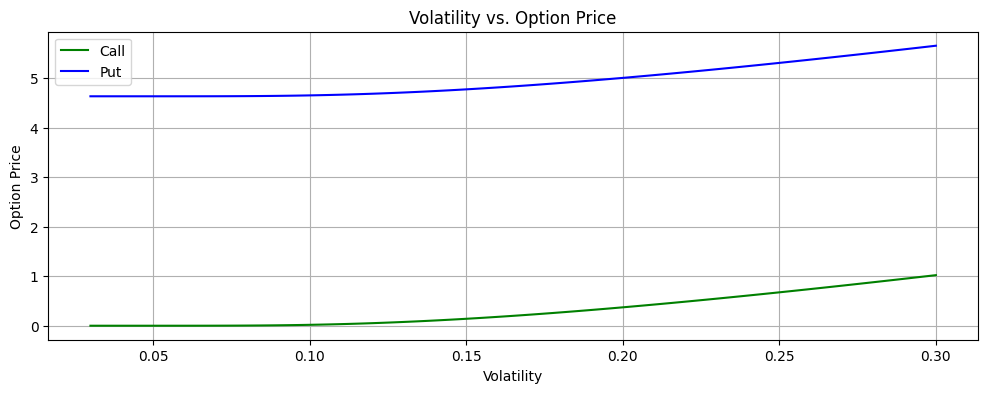

In [169]:
plt.figure(figsize=(12, 4))
plt.plot(df_sigma['Volatility'], df_sigma['Call Price'], label='Call', color='green')
plt.plot(df_sigma['Volatility'], df_sigma['Put Price'], label='Put', color='blue')
plt.xlabel('Volatility')
plt.ylabel('Option Price')
plt.title('Volatility vs. Option Price')
plt.grid()
plt.legend()
plt.show()

### Stock Price vs Option Price

In [170]:
def stock_sensitivity(K, T, r, sigma):
    
    stock_values = np.linspace(60, 140, 100)
    call_prices_stock = []
    put_prices_stock = []
    
    for S in stock_values:
        
        d1 = (np.log(S/K) + (r + (0.5 * sigma ** 2)) * T) / (sigma * np.sqrt(T))
        d2 = d1 - (sigma * np.sqrt(T))
        
        call = (S * norm.cdf(d1)) - (K * np.exp(-r * T) * norm.cdf(d2))
        put = (K * np.exp(-r * T) * norm.cdf(-d2)) - (S * norm.cdf(-d1))
        
        lhs = call - put
        rhs = S - (K * np.exp(-r * T))
        violations = 0
        
        if abs(lhs - rhs) >= 0.0001:
            violations += 1

        call_prices_stock.append(call)
        put_prices_stock.append(put)
            

    if violations == 0:
        print("Put-call parity holds for all stock prices.")

    else:
        print(f"Put-call parity violated for {violations} stock prices.")
        
    df_stock = pd.DataFrame({
    'Stock Price': stock_values,
    'Call Price': call_prices_stock,
    'Put Price': put_prices_stock
    })

    return df_stock

In [171]:
pd.set_option('display.float_format', '{:.10f}'.format)

df_stock = stock_sensitivity(K, T, r, sigma)

Put-call parity holds for all stock prices.


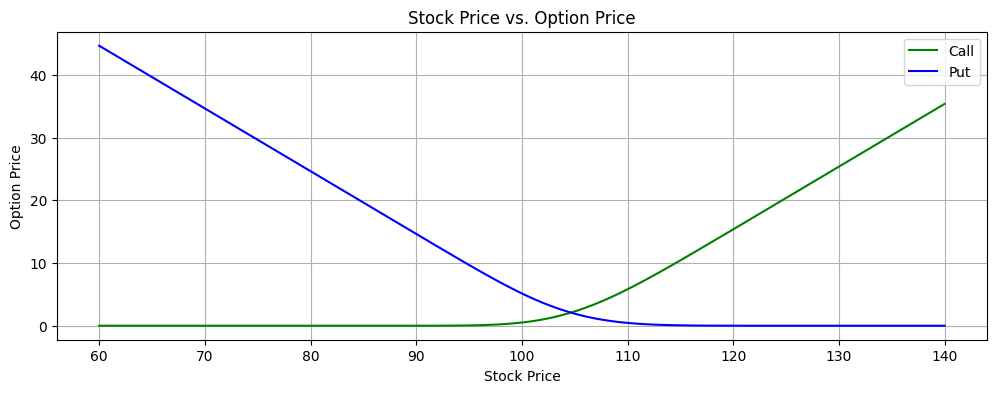

In [172]:
plt.figure(figsize=(12, 4))
plt.plot(df_stock['Stock Price'], df_stock['Call Price'], label='Call', color='green')
plt.plot(df_stock['Stock Price'], df_stock['Put Price'], label='Put', color='blue')
plt.xlabel('Stock Price')
plt.ylabel('Option Price')
plt.title('Stock Price vs. Option Price')
plt.grid()
plt.legend()
plt.show()

### Time to Expiry vs Option Price

In [173]:
def time_sensitivity(S, K, r, sigma):
    
    T_values = np.linspace(0.1, 2, 100)
    call_prices_T = []
    put_prices_T = []
    
    for T in T_values:
        
        d1 = (np.log(S/K) + (r + (0.5 * sigma ** 2)) * T) / (sigma * np.sqrt(T))
        d2 = d1 - (sigma * np.sqrt(T))
        
        
        call = (S * norm.cdf(d1)) - (K * np.exp(-r * T) * norm.cdf(d2))
        put = (K * np.exp(-r * T) * norm.cdf(-d2)) - (S * norm.cdf(-d1))
        
        lhs = call - put
        rhs = S - (K * np.exp(-r * T))
        violations = 0
        
        if abs(lhs - rhs) >= 0.0001:
            violations += 1

        call_prices_T.append(call)
        put_prices_T.append(put)
            

    if violations == 0:
        print("Put-call parity holds for all time values.")

    else:
        print(f"Put-call parity violated for {violations} time values.")
        
    df_T = pd.DataFrame({
    'Time to expiry': T_values,
    'Call Price': call_prices_T,
    'Put Price': put_prices_T
    })

    return df_T

In [174]:
pd.set_option('display.float_format', '{:.10f}'.format)

df_T = time_sensitivity(S, K, r, sigma)

Put-call parity holds for all time values.


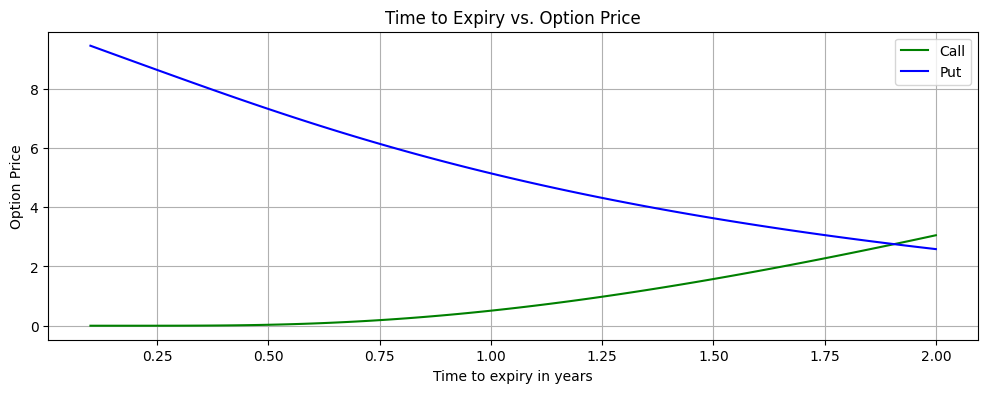

In [175]:
plt.figure(figsize=(12, 4))
plt.plot(df_T['Time to expiry'], df_T['Call Price'], label='Call', color='green')
plt.plot(df_T['Time to expiry'], df_T['Put Price'], label='Put', color='blue')
plt.xlabel('Time to expiry in years')
plt.ylabel('Option Price')
plt.title('Time to Expiry vs. Option Price')
plt.grid()
plt.legend()
plt.show()

## Options Payoff

In [176]:
S_range = np.linspace(60, 140, 100)

def option_payoff(K, S_range, bs_call_price, bs_cput_price):
    
    call_payoff = np.maximum(S_range - K, 0)
    put_payoff = np.maximum(K - S_range, 0)

    call_profit = call_payoff - bs_call_price
    put_profit = put_payoff - bs_put_price

    return call_payoff, put_payoff, call_profit, put_profit

In [178]:
call_payoff, put_payoff, call_profit, put_profit = option_payoff(K, S_range, bs_call_price, bs_put_price)

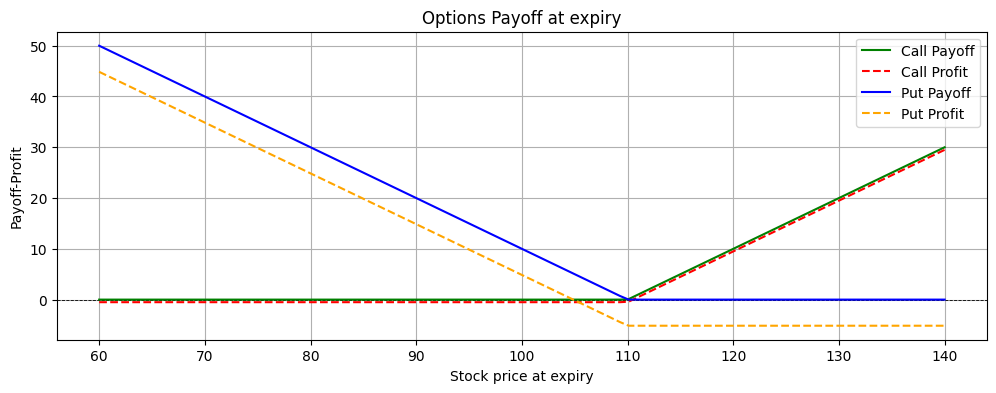

In [180]:
plt.figure(figsize=(12, 4))
plt.axhline(y=0, color='black', linewidth=0.6, linestyle='--')
plt.plot(S_range, call_payoff, label='Call Payoff', color='green')
plt.plot(S_range, call_profit, label='Call Profit', color='red', linestyle='--')
plt.plot(S_range, put_payoff, label='Put Payoff', color='blue')
plt.plot(S_range, put_profit, label='Put Profit', color='orange', linestyle='--')
plt.xlabel('Stock price at expiry')
plt.ylabel('Payoff-Profit')
plt.title('Options Payoff at expiry')
plt.grid()
plt.legend()
plt.show()

## The Greeks

### Delta

$$\Delta_C = N(d_1)$$
$$\newline$$
$$\Delta_P = N(d_1) - 1$$

In [113]:
def calculate_delta(d1, d2):
    
    delta_c = norm.cdf(d1)
    
    delta_p = norm.cdf(d1) - 1

    return delta_c, delta_p

In [114]:
call_delta, put_delta = calculate_delta(d1, d2)

### Theta

$$\theta_C = (-S \cdot N'(d_1) \cdot \frac{\sigma}{2} \cdot \sqrt{T}) - (r \cdot K \cdot e^{-rT} \cdot N'(d_2))$$
$$\newline$$
$$\theta_P = (-S \cdot N'(d_1) \cdot \frac{\sigma}{2} \cdot \sqrt{T}) + (r \cdot K \cdot e^{-rT} \cdot N'(-d_2))$$

In [115]:
def calculate_theta(S, K, T, r, sigma, d1, d2):
    
    theta_c = (-S * norm.pdf(d1) * sigma / 2 * np.sqrt(T)) - (r * K * np.exp(-r * T) * norm.pdf(d2))

    theta_p = (-S * norm.pdf(d1) * sigma / 2 * np.sqrt(T)) + (r * K * np.exp(-r * T) * norm.pdf(-d2))

    return theta_c, theta_p

In [116]:
call_theta, put_theta = calculate_theta(S, K, T, r, sigma, d1, d2)

### Rho

$$\rho_C = K \cdot T \cdot e^{-rT} \cdot N(d_2)$$
$$\newline$$
$$\rho_P = -K \cdot T \cdot e^{-rT} \cdot N(-d_2)$$

In [117]:
def calculate_rho(K, T, r, d2):

    rho_c = K * T * np.exp(-r * T) * norm.cdf(d2)
    
    rho_p = -K * T * np.exp(-r * T) * norm.cdf(-d2)

    return rho_c, rho_p

In [118]:
call_rho, put_rho = calculate_rho(K, T, r, d2)

### Vega

$$V_C = S \cdot N'(d_1) \cdot T = V_P$$

In [119]:
def calculate_vega(S, T, d1):

    vega = S * norm.pdf(d1) * T

    return vega

In [120]:
call_vega = calculate_vega(S, T, d1)

put_vega = call_vega

### Gamma

$$\gamma_C = \frac{N'(d_1)}{S \cdot \sigma \cdot \sqrt{T}} = \gamma_P$$

In [121]:
def calculate_gamma(S, T, sigma, d1):
    
    gamma = (norm.pdf(d1)) / (S * sigma * np.sqrt(T))

    return gamma

In [122]:
call_gamma = calculate_gamma(S, T, sigma, d1)

put_gamma = call_gamma

## Greeks Visualization

In [125]:
S_range = np.linspace(60, 140, 100)

d1 = (np.log(S_range/K) + (r + (0.5 * sigma ** 2)) * T) / (sigma * np.sqrt(T))
d2 = d1 - (sigma * np.sqrt(T))

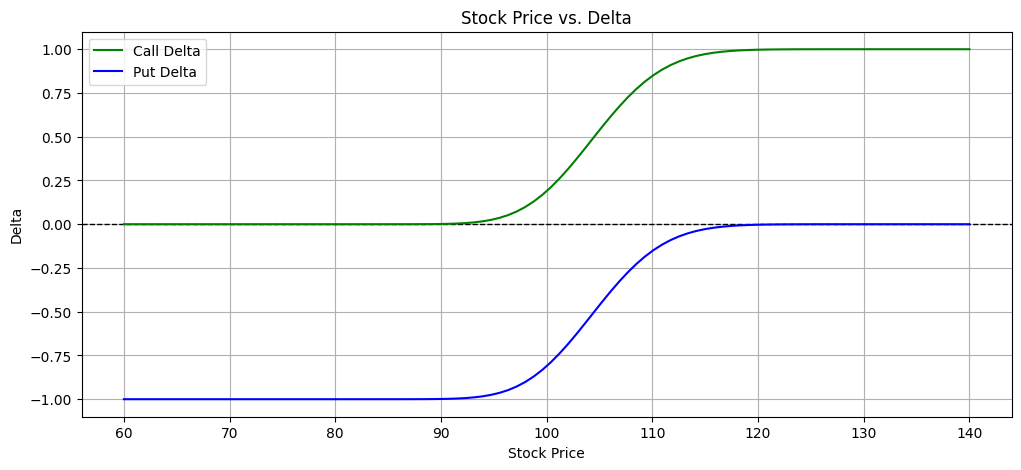

In [126]:
delta_call = norm.cdf(d1)
delta_put = norm.cdf(d1) -1

plt.figure(figsize=(12, 5))
plt.axhline(y=0, color='black', linewidth=1.0, linestyle='--')
plt.plot(S_range, delta_call, label='Call Delta', color='green')
plt.plot(S_range, delta_put, label='Put Delta', color='blue')
plt.xlabel('Stock Price')
plt.ylabel('Delta')
plt.title('Stock Price vs. Delta')
plt.grid()
plt.legend()
plt.show() 

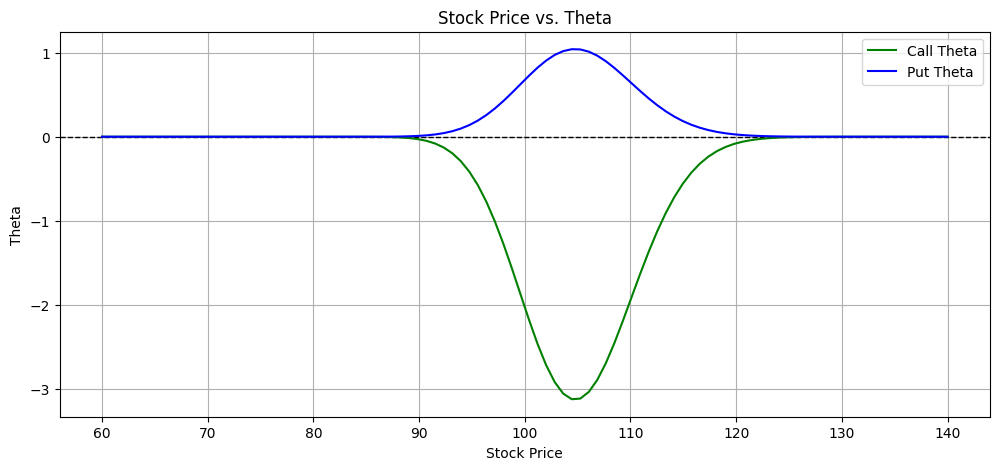

In [127]:
theta_call = (-S_range * norm.pdf(d1) * sigma / 2 * np.sqrt(T)) - (r * K * np.exp(-r * T) * norm.pdf(d2))

theta_put = (-S_range * norm.pdf(d1) * sigma / 2 * np.sqrt(T)) + (r * K * np.exp(-r * T) * norm.pdf(-d2))

plt.figure(figsize=(12, 5))
plt.axhline(y=0, color='black', linewidth=1.0, linestyle='--')
plt.plot(S_range, theta_call, label='Call Theta', color='green')
plt.plot(S_range, theta_put, label='Put Theta', color='blue')
plt.xlabel('Stock Price')
plt.ylabel('Theta')
plt.title('Stock Price vs. Theta')
plt.grid()
plt.legend()
plt.show() 

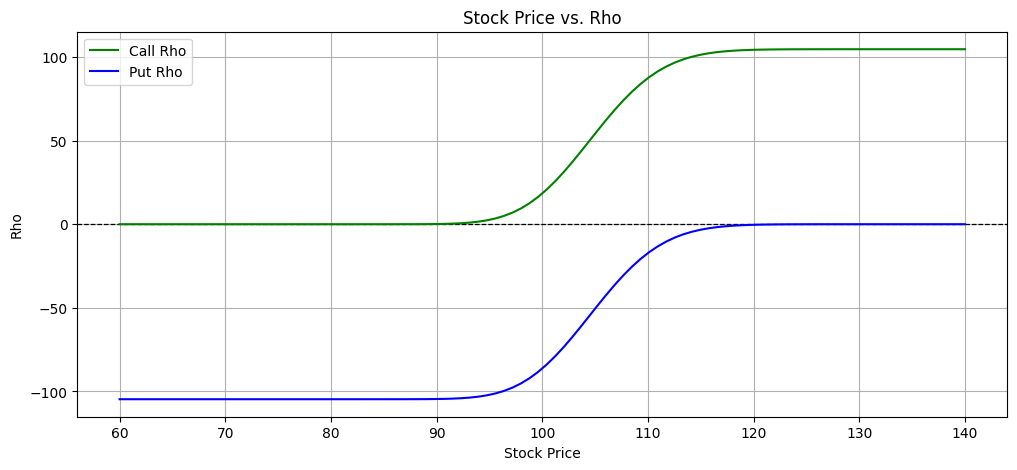

In [138]:
rho_call = K * T * np.exp(-r * T) * norm.cdf(d2)
rho_put = -K * T * np.exp(-r * T) * norm.cdf(-d2)

plt.figure(figsize=(12, 5))
plt.axhline(y=0, color='black', linewidth=0.9, linestyle='--')
plt.plot(S_range, rho_call, label='Call Rho', color='green')
plt.plot(S_range, rho_put, label='Put Rho', color='blue')
plt.xlabel('Stock Price')
plt.ylabel('Rho')
plt.title('Stock Price vs. Rho')
plt.grid()
plt.legend()
plt.show()

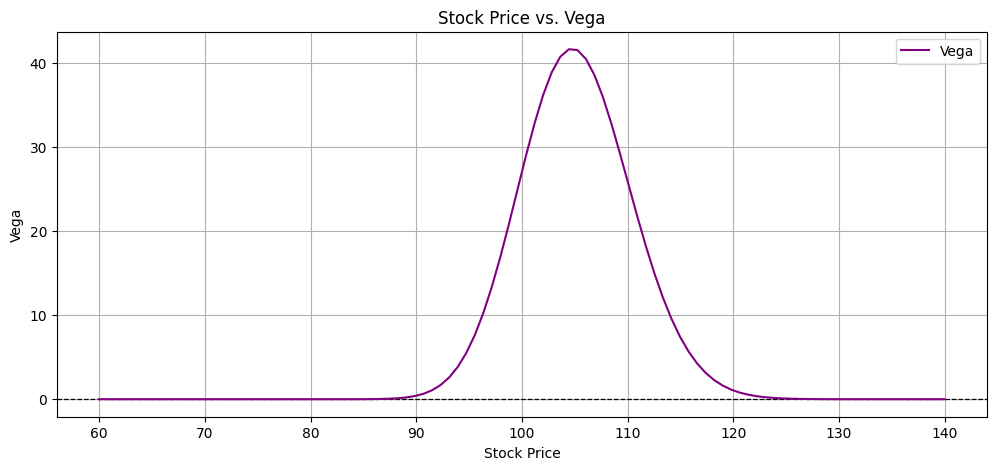

In [139]:
vega = S_range * norm.pdf(d1) * T

plt.figure(figsize=(12, 5))
plt.axhline(y=0, color='black', linewidth=0.9, linestyle='--')
plt.plot(S_range, vega, label='Vega', color='purple')
plt.xlabel('Stock Price')
plt.ylabel('Vega')
plt.title('Stock Price vs. Vega')
plt.grid()
plt.legend()
plt.show()

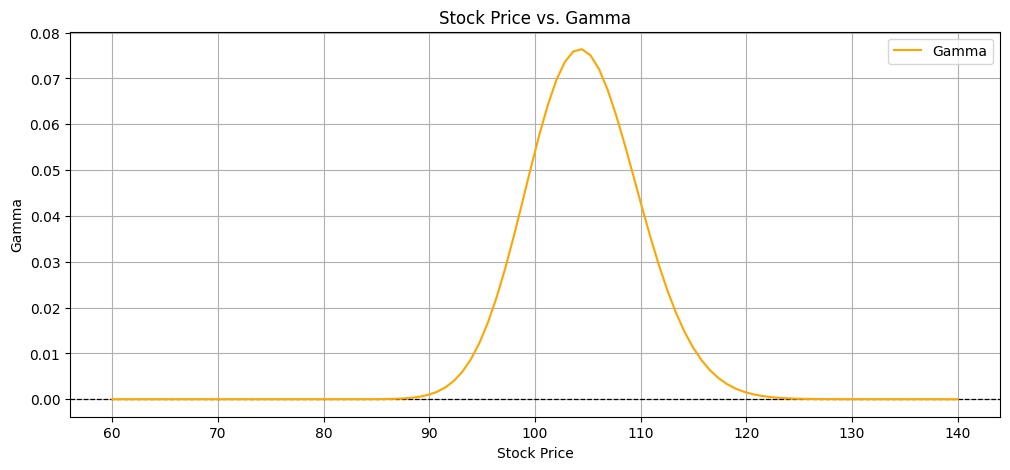

In [140]:
gamma = (norm.pdf(d1)) / (S_range * sigma * np.sqrt(T))

plt.figure(figsize=(12, 5))
plt.axhline(y=0, color='black', linewidth=0.9, linestyle='--')
plt.plot(S_range, gamma, label='Gamma', color='orange')
plt.xlabel('Stock Price')
plt.ylabel('Gamma')
plt.title('Stock Price vs. Gamma')
plt.grid()
plt.legend()
plt.show()

## Implied Volatility

In [141]:
option_type = str(input("Enter the option type (call or put): ")).strip().lower()

market_price = float(input(f"Enter the market price of the {option_type} option: "))

def implied_vol(S, K, r, T, market_price, option_type):
    
    sigma = 0.2   #initial guess

    for i in range(1000):

        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T ) / (sigma * np.sqrt(T))
        d2 = d1 - (sigma * np.sqrt(T))

        vega = S * norm.pdf(d1) * np.sqrt(T)

        if option_type == 'call':
            bs_price = (S * norm.cdf(d1)) - (K * np.exp(-r * T) * norm.cdf(d2))

        elif option_type == 'put':
            bs_price = (K * np.exp(-r * T) * norm.cdf(-d2)) - (S * norm.cdf(-d1))

        if abs(bs_price - market_price) < 0.0001:
            return sigma

        sigma = sigma - (bs_price - market_price) / vega

    print("Did not converge")
    return None

Enter the option type (call or put):  Put
Enter the market price of the put option:  5


In [142]:
implied_vol = implied_vol(S, K, r, T, market_price, option_type)

In [143]:
print(f"Implied Volatility: {implied_vol:.4f}")

Implied Volatility: 0.0444


## Monte Carlo Simulation for Options Pricing

In [144]:
n_sim = 50000

Z_list = np.random.standard_normal(n_sim)

def monte_carlo(S, T, K, r, sigma, Z_list):
    
    S_t = S * np.exp((r - (0.5 * sigma ** 2)) * T + (sigma * np.sqrt(T) * Z_list))

    mc_call_payoff = np.maximum(S_t - K, 0)
    mc_put_payoff = np.maximum(K - S_t, 0)
    
    mc_call_price = np.exp(-r * T) * np.mean(mc_call_payoff)
    mc_put_price = np.exp(-r * T) * np.mean(mc_put_payoff)
        
    return mc_call_price, mc_put_price

In [145]:
mc_call_price, mc_put_price = monte_carlo(S, T, K, r, sigma, Z_list)

In [151]:
print(f"Monte Carlo Call Price: ${mc_call_price:.4f}")

print(f"Monte Carlo Put Price: ${mc_put_price:.4f}")

Monte Carlo Call Price: $0.5069
Monte Carlo Put Price: $5.1542


In [182]:
comparison = pd.DataFrame({
    'Method': ['Black-Scholes', 'Monte Carlo'],
    'Call Price':[np.round(bs_call_price, 4), np.round(mc_call_price, 4)],
    'Put Price': [np.round(bs_put_price, 4), np.round(mc_put_price, 4)]
})

print(comparison.to_string(index=False))

       Method   Call Price    Put Price
Black-Scholes 0.5078000000 5.1430000000
  Monte Carlo 0.5069000000 5.1542000000
